***Customer Segmentation & Churn Pattern Analytics in European Banking***

In [1]:
#importing frame works
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
#importing dataset
df=pd.read_csv('European_Bank.csv')
df.head()
df.shape


(10000, 14)

In [3]:
#Data exploration and validation

#check shape and columns

df.shape
df.columns.tolist()
    

['Year',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [4]:
#check datatypes

df.dtypes

Year                 int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [5]:
#check missing values
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
#basic statistics
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
#check for bad data zeroes or negetive 
chk=df.select_dtypes(include='number')
for col in chk:
    bad=df[df[col]<=0]
    print(f"{col}:{len(bad)} zeroes/negetives")


binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']
# 0 is valid here, ignore these

# 0 balance is valid, just tag them as a segment
df['BalanceSegment'] = df['Balance'].apply(
    lambda x: 'Zero' if x == 0 else ('Low' if x < 50000 else 'High')
)

cols_to_fix = ['CreditScore', 'Age', 'EstimatedSalary']

for col in cols_to_fix:
    median_val = df[df[col] > 0][col].median()
    df[col] = df[col].apply(lambda x: median_val if x <= 0 else x)
    print(f"{col}: fixed with median → {median_val}")


Year:0 zeroes/negetives
CustomerId:0 zeroes/negetives
CreditScore:0 zeroes/negetives
Age:0 zeroes/negetives
Tenure:413 zeroes/negetives
Balance:3617 zeroes/negetives
NumOfProducts:0 zeroes/negetives
HasCrCard:2945 zeroes/negetives
IsActiveMember:4849 zeroes/negetives
EstimatedSalary:0 zeroes/negetives
Exited:7963 zeroes/negetives
CreditScore: fixed with median → 652.0
Age: fixed with median → 37.0
EstimatedSalary: fixed with median → 100193.915


In [8]:
cols_to_fix

['CreditScore', 'Age', 'EstimatedSalary']

In [9]:
#remove non analytical columns
df.drop(columns=['Surname','CustomerId'] ,inplace=True)

In [10]:
#segmentation
#Age segmentation
df['AgeGroup']=pd.cut(df['Age'],
                       bins=[0,30,45,60,100],
labels=['<30','30-45','45-60','60+'])


#credit score segmentation
df['CreditBand']=pd.cut(df['CreditScore'],
                       bins=[0,580,670,850],
                       labels=['Low','Medium','High'])

#Balance segmentation
df['BalanceSegment']=df['Balance'].apply(lambda x: 'Zero' if x==0  else 'High')


#Tenure Group
df['TenureGroup']=pd.cut(df['Tenure'],
                         bins=[-1,2,5,10],
                             labels=['New','MidTerm','LongTerm'])
df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSegment,AgeGroup,CreditBand,TenureGroup
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Zero,30-45,Medium,New
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,High,30-45,Medium,New
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,High,30-45,Low,LongTerm
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Zero,30-45,High,New
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,High,30-45,High,New


In [11]:
df.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'BalanceSegment', 'AgeGroup', 'CreditBand',
       'TenureGroup'],
      dtype='str')

In [12]:
#churn analysis


total=len(df)
churned=df['Exited'].sum()
churn_rate= (churned /total)*100


print(f'total customers  {total}')
print(f'churned customer  {churned}')
print(f'retained customer  {total - churned}')
print(f'overall churn_rate  {churn_rate:.2f}%')

total customers  10000
churned customer  2037
retained customer  7963
overall churn_rate  20.37%


In [13]:
# Geograhy churn analysis

geo_churn=df.groupby('Geography')['Exited'].agg(['sum','mean']).reset_index()
geo_churn.columns=['Geography','ChurnCount','ChurnRate']
geo_churn['ChurnRate']=geo_churn['ChurnRate']*100
geo_churn

,Geography,ChurnCount,ChurnRate
0,France,810,16.154767
1,Germany,814,32.443204
2,Spain,413,16.673395


In [14]:
#Gender churn anlaysis

Gender_churn=df.groupby('Gender')['Exited'].agg(['sum','mean']).reset_index()
Gender_churn.columns=['Gender','ChurnCount','ChurnRate']
Gender_churn['ChurnRate']=Gender_churn['ChurnRate']*100
Gender_churn

,Gender,ChurnCount,ChurnRate
0,Female,1139,25.071539
1,Male,898,16.455928


In [15]:
#AgeGroup churn analysis

Age_churn=df.groupby('AgeGroup')['Exited'].agg(['sum','mean']).reset_index()
Age_churn.columns=['AgeGroup','ChurnCount','ChurnRate']
Age_churn['ChurnRate']=Age_churn['ChurnRate']*100
Age_churn

,AgeGroup,ChurnCount,ChurnRate
0,<30,148,7.520325
1,30-45,932,15.740584
2,45-60,842,51.123254
3,60+,115,24.784483


In [16]:
#CreditBand churn analysis

Credit_churn=df.groupby('CreditBand')['Exited'].agg(['sum','mean']).reset_index()
Credit_churn.columns=['CreditBand','ChurnCount','ChurnRate']
Credit_churn['ChurnRate']=Credit_churn['ChurnRate']*100
Credit_churn


,CreditBand,ChurnCount,ChurnRate
0,Low,530,22.147931
1,Medium,683,20.388060
2,High,824,19.356354


In [17]:
#balance churn analysis

Balance_churn=df.groupby('BalanceSegment')['Exited'].agg(['sum','mean']).reset_index()
Balance_churn.columns=['BalanceSegment','ChurnCount','ChurnRate']
Balance_churn['ChurnRate']=Balance_churn['ChurnRate']*100
Balance_churn

,BalanceSegment,ChurnCount,ChurnRate
0,High,1537,24.079586
1,Zero,500,13.823611


In [18]:
#Tenure Group churn analysis

TenureGroup=df.groupby('TenureGroup')['Exited'].agg(['sum','mean']).reset_index()
TenureGroup.columns=['TenureGroup','ChurnCount','ChurnRate']
TenureGroup['ChurnRate']=TenureGroup['ChurnRate']*100
TenureGroup

,TenureGroup,ChurnCount,ChurnRate
0,New,528,21.153846
1,MidTerm,625,20.764120
2,LongTerm,884,19.670672


***VISUALISATION***

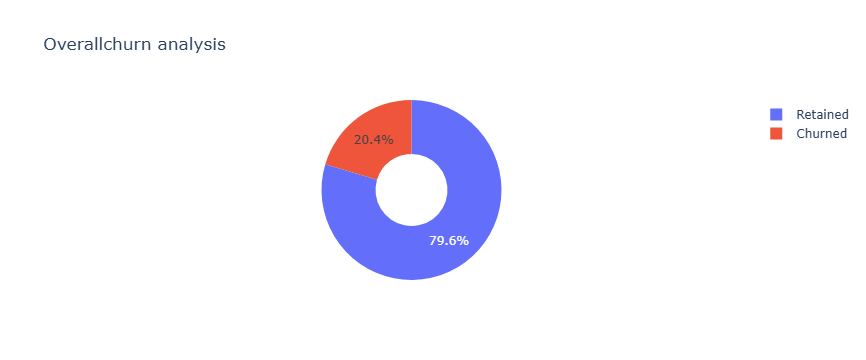

In [19]:
#Overall Churn pie/donut chart


churn_labels=df['Exited'].map({0:'Retained', 1:'Churned'})
churn_counts=churn_labels.value_counts().reset_index()
churn_counts.columns=['Status','Count']
fig=px.pie(churn_counts,
    names='Status',
    values='Count',
    hole=0.4,
       title='Overallchurn analysis'  )
         
fig.show()



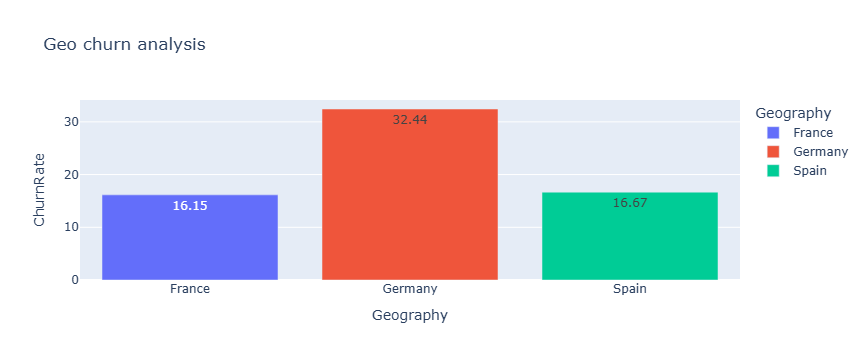

In [20]:
#Churn by Geography 
geo_churn['ChurnRate']=geo_churn['ChurnRate'].round(2)
fig=px.bar(geo_churn,
          title='Geo churn analysis',
          x='Geography',
          y='ChurnRate',
          color='Geography',
          text='ChurnRate')

fig.show()


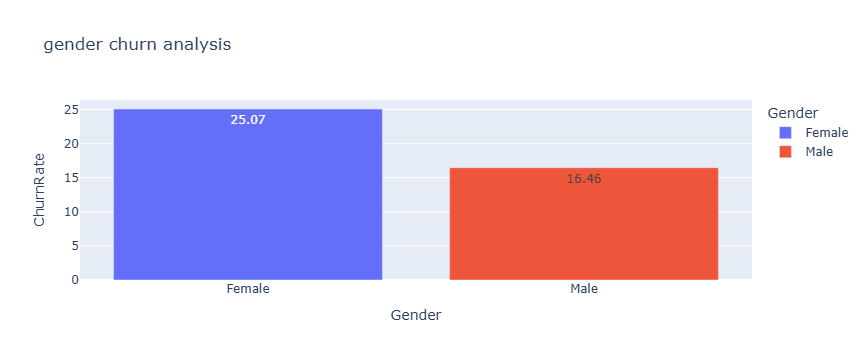

In [21]:
#Churn by Gender 
Gender_churn['ChurnRate']=Gender_churn['ChurnRate'].round(2)
fig=px.bar(Gender_churn,
          title='gender churn analysis',
          x='Gender',
          y='ChurnRate',
          color='Gender',
          text='ChurnRate')

fig.show()

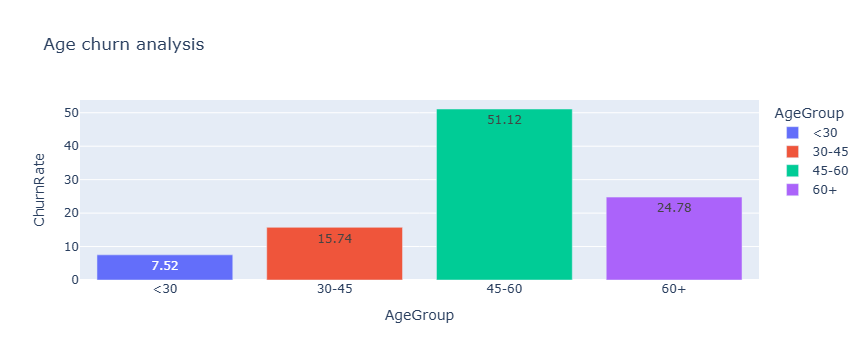

In [22]:
#Churn by Age Group 
Age_churn['ChurnRate']=Age_churn['ChurnRate'].round(2)
fig=px.bar(Age_churn,
          title='Age churn analysis',
          x='AgeGroup',
          y='ChurnRate',
          color='AgeGroup',
          text='ChurnRate',
          
          )

fig.show()

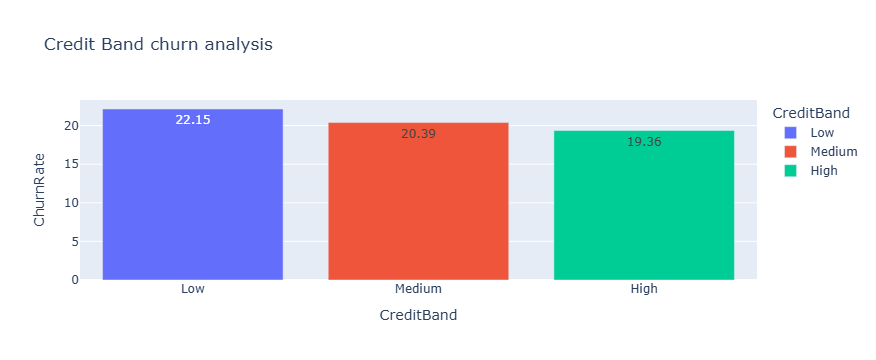

In [23]:
#Churn by creditBand

Credit_churn['ChurnRate']=Credit_churn['ChurnRate'].round(2)
fig=px.bar(Credit_churn,
          title='Credit Band churn analysis',
          x='CreditBand',
          y='ChurnRate',
          color='CreditBand',
          text='ChurnRate',
          
          )

fig.show()

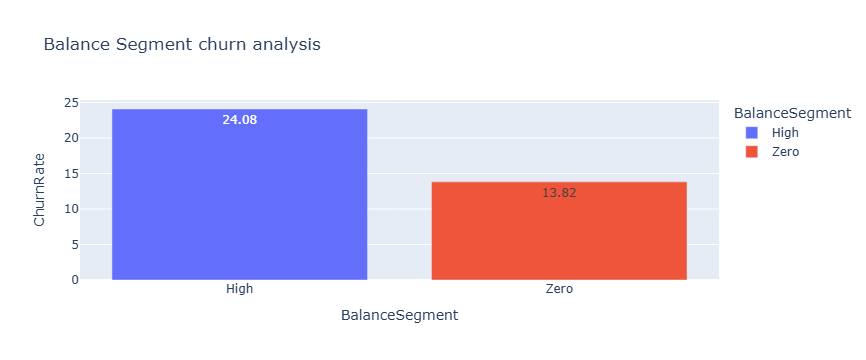

In [24]:
#Churn by Balance segment

Balance_churn['ChurnRate']=Balance_churn['ChurnRate'].round(2)
fig=px.bar(Balance_churn,
          title='Balance Segment churn analysis',
          x='BalanceSegment',
          y='ChurnRate',
          color='BalanceSegment',
          text='ChurnRate',
          
          )

fig.show()

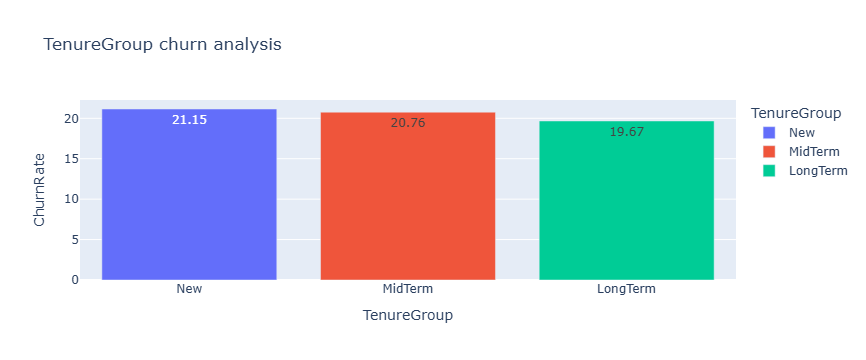

In [25]:
#Churn by Tenure group

TenureGroup['ChurnRate']=TenureGroup['ChurnRate'].round(2)
fig=px.bar(TenureGroup,
          title='TenureGroup churn analysis',
          x='TenureGroup',
          y='ChurnRate',
          color='TenureGroup',
          text='ChurnRate',
          
          )

fig.show()

In [26]:
df


,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSegment,AgeGroup,CreditBand,TenureGroup
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Zero,30-45,Medium,New
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,High,30-45,Medium,New
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,High,30-45,Low,LongTerm
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Zero,30-45,High,New
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,High,30-45,High,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,771,France,Male,39,5,0.00,2,1,0,96270.64,0,Zero,30-45,High,MidTerm
9996,2025,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,High,30-45,Low,LongTerm
9997,2025,709,France,Female,36,7,0.00,1,0,1,42085.58,1,Zero,30-45,High,LongTerm
9998,2025,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,High,30-45,High,MidTerm


In [27]:
print(df.columns.tolist())

['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'BalanceSegment', 'AgeGroup', 'CreditBand', 'TenureGroup']


In [28]:
df.to_csv('European_Bank.csv', index=False)